In [22]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.tools.tavily_search import TavilySearchResults

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [23]:
docs = (
    PyPDFLoader("./documents/Company_Policies.pdf").load()
    + PyPDFLoader("./documents/Company_Profile.pdf").load()
    + PyPDFLoader("./documents/Product_and_Pricing.pdf").load()
)

In [24]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [25]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

In [26]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Max number of rewrite_query -> web_search -> is_relevant loops before giving up
MAX_WEB_RETRIES = 2

In [27]:
# --------------------------------------------------
# Graph State
# --------------------------------------------------
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]
    relevant_docs: List[Document]     

    context: str # New ( merge all the relevent_docs)
    answer: str

    # Web-search fallback loop (replaces the old dead-end no_relevant_docs path)
    search_query: str
    retry_count: int

In [28]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


# IMPORTANT: no `.content` for structured output
should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: "State"):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

In [29]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }


In [30]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

In [31]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevance_llm = llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    
    relevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}



In [32]:
# New: rewrite query + web search fallback loop
# (replaces the old dead-end no_relevant_docs path)
class RewrittenQuery(BaseModel):
    query: str = Field(
        ...,
        description="A clear, specific web search query likely to find the missing information online."
    )

rewrite_query_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "The question could not be answered from the internal company documents.\n"
            "Rewrite it into a focused web search query that is likely to surface the missing\n"
            "information on the public internet.\n"
            "Return JSON with key: query."
        ),
        ("human", "Original question:\n{question}"),
    ]
)

rewrite_query_llm = llm.with_structured_output(RewrittenQuery)

def rewrite_query(state: State):
    decision: RewrittenQuery = rewrite_query_llm.invoke(
        rewrite_query_prompt.format_messages(question=state["question"])
    )
    return {
        "search_query": decision.query,
        "retry_count": state.get("retry_count", 0) + 1,
    }


tavily = TavilySearchResults(max_results=4)

def web_search(state: State):
    query = state.get("search_query") or state["question"]
    results = tavily.invoke({"query": query})

    if isinstance(results, str):
        # Tavily returned an error message (e.g. invalid/unauthorized API key)
        print("Tavily search failed:", results)
        results = []

    web_docs: List[Document] = []
    for r in results or []:
        if not isinstance(r, dict):
            print("Unexpected Tavily result (not a dict):", r)
            continue

        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"

        web_docs.append(Document(page_content=text, metadata={"url": url, "title": title, "source": "web"}))

    # Feed the fresh web results back into is_relevant for re-evaluation
    return {"docs": web_docs}

In [33]:
# New
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

def generate_from_context(state: State):
    # Stuff relevant docs into one block
    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs", [])]
    ).strip()

    if not context:
        return {"answer": "No relevant document found.", "context": ""}

    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question=state["question"],
            context=context
        )
    )
    return {"answer": out.content, "context": context}


In [34]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

In [35]:
# New
def route_after_relevance(state: State) -> Literal["generate_from_context", "rewrite_query"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    if state.get("retry_count", 0) < MAX_WEB_RETRIES:
        return "rewrite_query"
    return "generate_from_context"


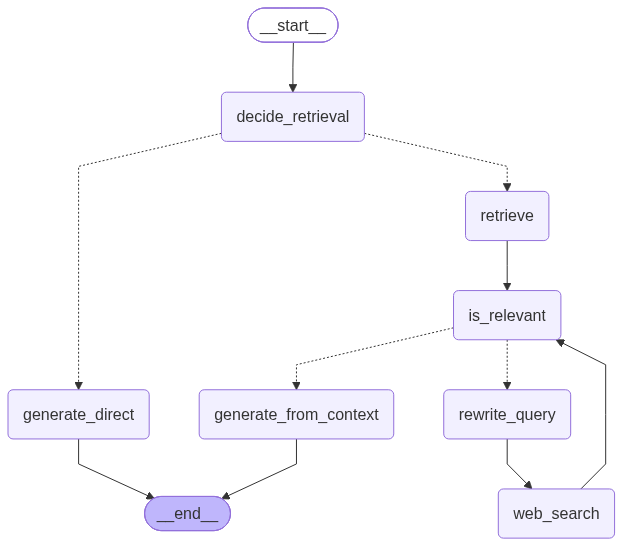

In [36]:
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)
g.add_node("is_relevant", is_relevant)
g.add_node("rewrite_query", rewrite_query)
g.add_node("web_search", web_search)
g.add_node("generate_from_context", generate_from_context)

g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("generate_direct", END)

g.add_edge("retrieve", "is_relevant")

g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context",
        "rewrite_query": "rewrite_query",
    },
)

# Web-search fallback loop: rewrite the query, search the web, then re-check relevance
g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "is_relevant")

g.add_edge("generate_from_context", END)

app = g.compile()

app

In [37]:
result = app.invoke(
    {
        "question": "What is the refund policy of NexaAI",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
        "search_query": "",
        "retry_count": 0,
    }
)

print(result["answer"])

Tavily search failed: HTTPError('401 Client Error: Unauthorized for url: https://api.tavily.com/search')
Tavily search failed: HTTPError('401 Client Error: Unauthorized for url: https://api.tavily.com/search')
No relevant document found.


In [38]:
result = app.invoke(
    {
        "question": "who is the ceo of NexaAI",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
        "search_query": "",
        "retry_count": 0,
    }
)

print(result["answer"])

The CEO of NexaAI is Aarav Mehta.


In [39]:
# Who is the CEO of NexaAI?
# What is the refund policy of NexaAI

In [40]:
for doc in result['relevant_docs']:
    print(doc.page_content)
    print("*"*100)

Founder
Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and
cloud infrastructure.
He previously worked with global consulting firms where he led multiple large-scale digital
transformation projects.
Leadership Team
The leadership team brings experience across AI engineering, product management, and business
operations.

Aarav Mehta – CEO & Founder

Riya Kapoor – CTO (Distributed systems & AI platforms)

Kunal Sharma – Head of Product

Neha Verma – Head of Operations & HR

Siddharth Rao – Head of Sales & Partnerships
****************************************************************************************************


In [41]:
result = app.invoke(
    {
        "question": "What is the refund policy of NexaAI",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
        "search_query": "",
        "retry_count": 0,
    }
)

print(result["answer"])

Tavily search failed: HTTPError('401 Client Error: Unauthorized for url: https://api.tavily.com/search')
Tavily search failed: HTTPError('401 Client Error: Unauthorized for url: https://api.tavily.com/search')
No relevant document found.
